# Лабораторная работа 12 Клименчук Илья ИПО-2-2022

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Цель: реализовать и исследовать генеративно‑состязательную сеть, которая по случайному шуму синтезирует изображения цифр в стиле MNIST, а также сравнить несколько вариаций архитектуры и гиперпараметров.



## 1. Ваше понимание задачи GAN

Перед запуском кода полезно сформулировать исходное понимание идеи GAN своими словами: чем генерация отличается от обычной классификации, почему обучение генератора и дискриминатора похоже на игру с противостоящими целями и какие трудности возникают на практике.


In [1]:
intro_text = """GAN нужен не для того, чтобы присвоить объекту метку класса, а для того, чтобы научиться создавать новые примеры, похожие на объекты из обучающего набора. 
В такой модели есть две части: генератор и дискриминатор. 
Генератор получает на вход случайный шум и пытается превратить его в изображение, которое будет выглядеть как настоящее. 
Дискриминатор, наоборот, получает либо реальное изображение из датасета, либо картинку, созданную генератором, и пытается определить, где подделка. 
Получается своеобразная игра: генератор хочет обмануть дискриминатор, а дискриминатор хочет не дать себя обмануть. 
Из-за этого обучение GAN не такое устойчивое, как у обычной нейросети для классификации, потому что обе части сети постоянно меняют условия задачи друг для друга. 
Если дискриминатор становится слишком сильным, генератору трудно получать полезный градиент; если же генератор внезапно начинает хорошо обманывать, дискриминатор временно проигрывает. 
Для простого Vanilla GAN на MNIST я ожидаю увидеть сначала шумные пятна и неразборчивые контуры, а затем более узнаваемые цифры. 
При этом часть изображений всё равно может оставаться странной: цифры могут быть расплывчатыми, неполными или выглядеть как гибриды нескольких классов сразу. 
Особенно интересно посмотреть, как на итоговое качество повлияют размер латентного вектора, глубина сетей и стабилизирующие приёмы вроде BatchNorm или Dropout."""
print(intro_text)

GAN нужен не для того, чтобы присвоить объекту метку класса, а для того, чтобы научиться создавать новые примеры, похожие на объекты из обучающего набора. 
В такой модели есть две части: генератор и дискриминатор. 
Генератор получает на вход случайный шум и пытается превратить его в изображение, которое будет выглядеть как настоящее. 
Дискриминатор, наоборот, получает либо реальное изображение из датасета, либо картинку, созданную генератором, и пытается определить, где подделка. 
Получается своеобразная игра: генератор хочет обмануть дискриминатор, а дискриминатор хочет не дать себя обмануть. 
Из-за этого обучение GAN не такое устойчивое, как у обычной нейросети для классификации, потому что обе части сети постоянно меняют условия задачи друг для друга. 
Если дискриминатор становится слишком сильным, генератору трудно получать полезный градиент; если же генератор внезапно начинает хорошо обманывать, дискриминатор временно проигрывает. 
Для простого Vanilla GAN на MNIST я ожидаю увидет

## 2. Импорт библиотек, настройка среды и загрузка данных

In [2]:
import random
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset

# Небольшой патч для окружений, где torchvision падает из-за отсутствующего torchvision::nms
_original_register_fake = torch.library.register_fake

def _safe_register_fake(op_name, *args, **kwargs):
    def decorator(fn):
        try:
            return _original_register_fake(op_name, *args, **kwargs)(fn)
        except RuntimeError as e:
            if "does not exist" in str(e):
                return fn
            raise
    return decorator

torch.library.register_fake = _safe_register_fake

from torchvision import datasets, transforms, utils
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.set_num_threads(1)
plt.rcParams["figure.figsize"] = (8, 4)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

data_root = Path("./data")
data_root.mkdir(parents=True, exist_ok=True)
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # переводим пиксели в [-1, 1]
])

batch_size = 128
mnist_subset_limit = 15000  # чтобы ноутбук запускался заметно быстрее на CPU; можно поставить None

def load_mnist_or_fallback():
    try:
        train_dataset = datasets.MNIST(
            root=data_root,
            train=True,
            download=True,
            transform=transform,
        )
        dataset_name = "MNIST"
        fallback_used = False

        if mnist_subset_limit is not None and mnist_subset_limit < len(train_dataset):
            subset_indices = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(MY_SEED))[:mnist_subset_limit]
            train_dataset = Subset(train_dataset, subset_indices.tolist())
            dataset_name += f" (подвыборка {len(train_dataset)} объектов для ускорения)"
    except Exception as e:
        digits = load_digits()
        X = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
        X = F.interpolate(X, size=(28, 28), mode="bilinear", align_corners=False)
        X = X * 2.0 - 1.0  # тоже приводим к [-1, 1]
        y = torch.tensor(digits.target, dtype=torch.long)

        indices = np.arange(len(X))
        train_idx, _ = train_test_split(
            indices,
            test_size=0.25,
            random_state=MY_SEED,
            stratify=y.numpy()
        )

        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        dataset_name = "sklearn digits (fallback, масштабировано до 28x28)"
        fallback_used = True

        print("Не удалось скачать MNIST. Использую запасной набор digits.")
        print("Текст ошибки:", str(e))

    return train_dataset, dataset_name, fallback_used

train_dataset, dataset_name, fallback_used = load_mnist_or_fallback()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("Используемый набор данных:", dataset_name)
print("Размер train:", len(train_dataset))
print("Batch size  :", batch_size)

Устройство: cpu
MY_SEED = 42
Используемый набор данных: MNIST (подвыборка 15000 объектов для ускорения)
Размер train: 15000
Batch size  : 128


Посмотрим на несколько реальных изображений, которые генератору предстоит имитировать.

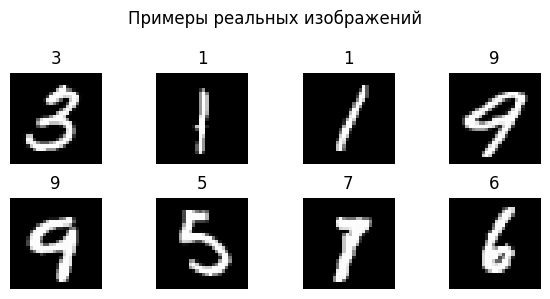

In [3]:
real_images, real_labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0).cpu(), cmap="gray")
    plt.title(str(int(real_labels[i])))
    plt.axis("off")

plt.suptitle("Примеры реальных изображений")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Здесь полезно отметить, насколько рукописные цифры кажутся простыми или сложными для генерации, какие классы более разнообразны по написанию и почему даже визуально несложный датасет всё равно не гарантирует стабильного обучения GAN.


In [4]:
data_comment = """С одной стороны, MNIST кажется относительно простым набором данных для генерации: изображения маленькие, одноканальные и содержат всего один объект на тёмном фоне. 
С другой стороны, даже у рукописных цифр есть заметная вариативность: отличаются наклон, толщина линий, ширина штрихов, форма замкнутых областей и общая «аккуратность» написания. 
Особенно неоднозначными могут быть пары вроде 1 и 7, 3 и 5, 4 и 9, где границы между классами иногда визуально размыты. 
Из-за этого генератору недостаточно просто рисовать белое пятно в центре кадра: ему нужно научиться воспроизводить правдоподобные контуры, пропорции и характерные детали цифр. 
Поэтому даже на таком датасете итоговое качество сильно зависит не только от данных, но и от баланса обучения генератора и дискриминатора."""
print(data_comment)

С одной стороны, MNIST кажется относительно простым набором данных для генерации: изображения маленькие, одноканальные и содержат всего один объект на тёмном фоне. 
С другой стороны, даже у рукописных цифр есть заметная вариативность: отличаются наклон, толщина линий, ширина штрихов, форма замкнутых областей и общая «аккуратность» написания. 
Особенно неоднозначными могут быть пары вроде 1 и 7, 3 и 5, 4 и 9, где границы между классами иногда визуально размыты. 
Из-за этого генератору недостаточно просто рисовать белое пятно в центре кадра: ему нужно научиться воспроизводить правдоподобные контуры, пропорции и характерные детали цифр. 
Поэтому даже на таком датасете итоговое качество сильно зависит не только от данных, но и от баланса обучения генератора и дискриминатора.


## 3. Архитектура генератора и дискриминатора

В базовой версии используем полносвязный **Vanilla GAN**:
- генератор получает на вход случайный вектор `z` и выдаёт изображение `28×28`;
- дискриминатор получает изображение и оценивает вероятность того, что оно реальное.

Ниже архитектуры сделаны параметризуемыми, чтобы затем удобно запускать собственные вариации.


In [5]:
img_dim = 28 * 28
z_dim = 100

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim, hidden_dims=(256, 512, 1024), use_batchnorm=False, activation="relu"):
        super().__init__()

        layers = []
        in_dim = z_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            if activation == "relu":
                layers.append(nn.ReLU(True))
            else:
                layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_dim = h

        layers.append(nn.Linear(in_dim, img_dim))
        layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        img = self.net(z)
        return img.view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self, img_dim, hidden_dims=(512, 256), dropout=0.0):
        super().__init__()

        layers = [nn.Flatten()]
        in_dim = img_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim=z_dim, img_dim=img_dim).to(device)
D = Discriminator(img_dim=img_dim).to(device)

print(G)
print()
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Нужно пояснить, почему у генератора на выходе стоит `tanh`, зачем дискриминатору `LeakyReLU`, и как это связано с нормализацией входных данных.


In [6]:
arch_comment = """Функция tanh на выходе генератора удобна тем, что она ограничивает значения пикселей диапазоном [-1, 1]. 
Это хорошо сочетается с нормализацией входных данных в тот же диапазон: дискриминатор видит реальные и сгенерированные изображения в одной шкале, и генератору не нужно дополнительно подгонять амплитуду пикселей. 
Если бы реальные изображения оставались в [0, 1], а генератор выдавал бы [-1, 1], дискриминатор получил бы слишком простую подсказку и быстро научился бы различать тип источника. 
В дискриминаторе используется LeakyReLU, потому что она меньше страдает от «отмирания» нейронов, чем обычная ReLU. 
Для GAN это особенно полезно: обучение и так нестабильное, поэтому нежелательно терять часть нейронов из-за нулевого градиента на отрицательной части входа. 
В итоге такая комбинация активаций делает базовую архитектуру более удобной для состязательного обучения."""
print(arch_comment)

Функция tanh на выходе генератора удобна тем, что она ограничивает значения пикселей диапазоном [-1, 1]. 
Это хорошо сочетается с нормализацией входных данных в тот же диапазон: дискриминатор видит реальные и сгенерированные изображения в одной шкале, и генератору не нужно дополнительно подгонять амплитуду пикселей. 
Если бы реальные изображения оставались в [0, 1], а генератор выдавал бы [-1, 1], дискриминатор получил бы слишком простую подсказку и быстро научился бы различать тип источника. 
В дискриминаторе используется LeakyReLU, потому что она меньше страдает от «отмирания» нейронов, чем обычная ReLU. 
Для GAN это особенно полезно: обучение и так нестабильное, поэтому нежелательно терять часть нейронов из-за нулевого градиента на отрицательной части входа. 
В итоге такая комбинация активаций делает базовую архитектуру более удобной для состязательного обучения.


## 4. Функция потерь, оптимизаторы и вспомогательные функции

Используем бинарную кросс-энтропию и Adam. Для удобства сразу определим общую функцию обучения, которой потом воспользуемся и для базовой модели, и для дополнительных экспериментов.


In [7]:
criterion = nn.BCELoss()

def plot_generated_grid(images, title, nrow=8):
    grid = utils.make_grid(images, nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def build_gan(cfg):
    G = Generator(
        z_dim=cfg["z_dim"],
        img_dim=img_dim,
        hidden_dims=cfg.get("g_hidden_dims", (256, 512, 1024)),
        use_batchnorm=cfg.get("g_batchnorm", False),
        activation=cfg.get("g_activation", "relu"),
    ).to(device)

    D = Discriminator(
        img_dim=img_dim,
        hidden_dims=cfg.get("d_hidden_dims", (512, 256)),
        dropout=cfg.get("d_dropout", 0.0),
    ).to(device)

    return G, D


def fit_gan(G, D, cfg, train_loader, sample_every=4, show_samples=True):
    z_dim = cfg["z_dim"]
    epochs = cfg.get("epochs", 10)
    lr_G = cfg.get("lr_G", 2e-4)
    lr_D = cfg.get("lr_D", 2e-4)
    beta1 = cfg.get("beta1", 0.5)
    label_smoothing = cfg.get("label_smoothing", False)

    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

    fixed_z = torch.randn(64, z_dim, device=device)

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, epochs + 1):
        G.train()
        D.train()

        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            real_targets = torch.full((bs, 1), 0.9 if label_smoothing else 1.0, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)

            # --- шаг дискриминатора ---
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_targets)

            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_targets)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, torch.ones(bs, 1, device=device))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch:02d}/{epochs} | loss_G={avg_loss_G:.4f} | loss_D={avg_loss_D:.4f}")

        if show_samples and (epoch == 1 or epoch % sample_every == 0 or epoch == epochs):
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            plot_generated_grid(samples, f"{cfg['name']}: сгенерированные изображения, эпоха {epoch}")

    G.eval()
    with torch.no_grad():
        final_samples = G(fixed_z).cpu()

    history = {
        "loss_G": loss_history_G,
        "loss_D": loss_history_D,
    }
    return history, final_samples

## 5. Базовый запуск Vanilla GAN

Сначала обучим стандартную конфигурацию, а затем проанализируем динамику лоссов и визуальное качество генерации.


Эпоха 01/12 | loss_G=0.7606 | loss_D=1.2437


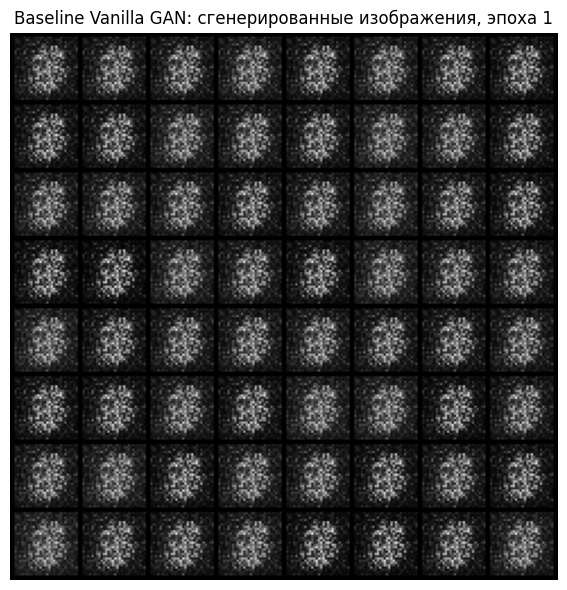

Эпоха 02/12 | loss_G=0.8305 | loss_D=1.2816
Эпоха 03/12 | loss_G=1.1128 | loss_D=1.0560
Эпоха 04/12 | loss_G=1.4636 | loss_D=0.9830


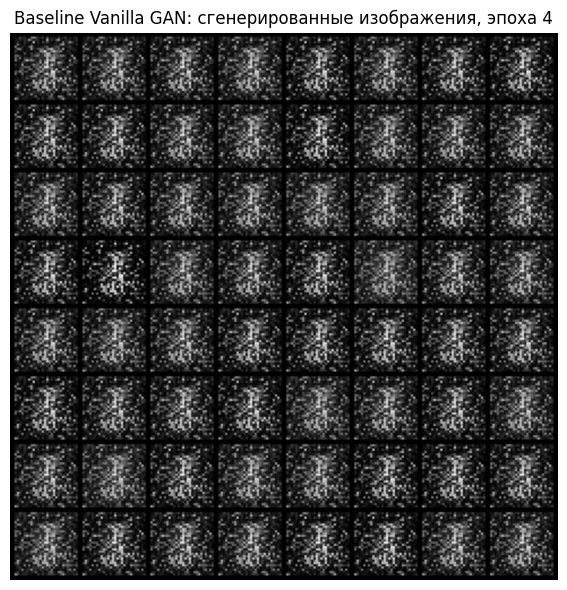

Эпоха 05/12 | loss_G=2.3557 | loss_D=0.7920
Эпоха 06/12 | loss_G=2.4866 | loss_D=0.7646
Эпоха 07/12 | loss_G=2.5618 | loss_D=0.7322
Эпоха 08/12 | loss_G=2.5162 | loss_D=0.7685


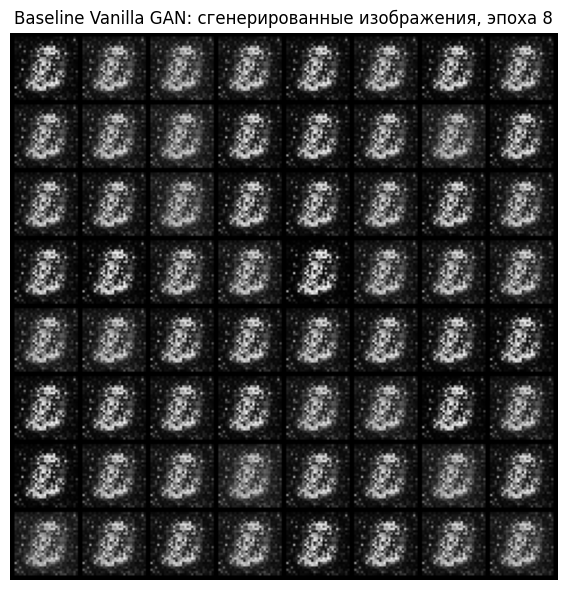

Эпоха 09/12 | loss_G=2.7066 | loss_D=0.6639
Эпоха 10/12 | loss_G=3.0311 | loss_D=0.6298
Эпоха 11/12 | loss_G=3.2160 | loss_D=0.6614
Эпоха 12/12 | loss_G=3.4922 | loss_D=0.4946


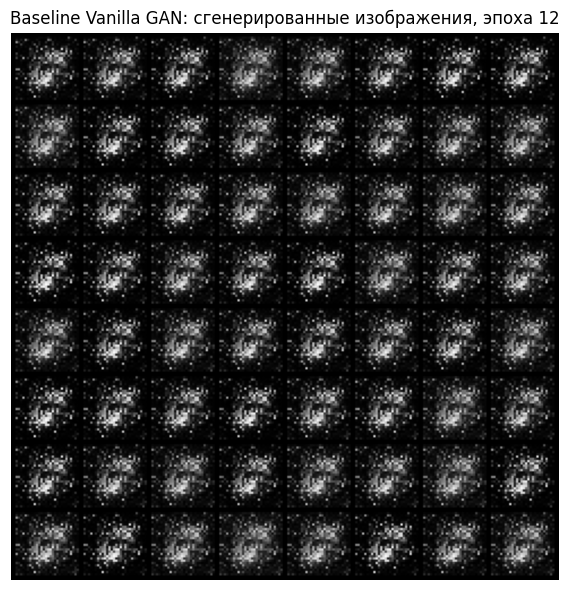

In [8]:
baseline_cfg = {
    "name": "Baseline Vanilla GAN",
    "z_dim": 100,
    "g_hidden_dims": (256, 512, 1024),
    "d_hidden_dims": (512, 256),
    "g_batchnorm": False,
    "g_activation": "relu",
    "d_dropout": 0.0,
    "epochs": 12,
    "lr_G": 2e-4,
    "lr_D": 2e-4,
    "beta1": 0.5,
    "label_smoothing": False,
}

G, D = build_gan(baseline_cfg)
baseline_history, baseline_samples = fit_gan(G, D, baseline_cfg, train_loader, sample_every=4, show_samples=True)

loss_G = baseline_history["loss_G"]
loss_D = baseline_history["loss_D"]
num_epochs = baseline_cfg["epochs"]

## 6. Графики лоссов генератора и дискриминатора

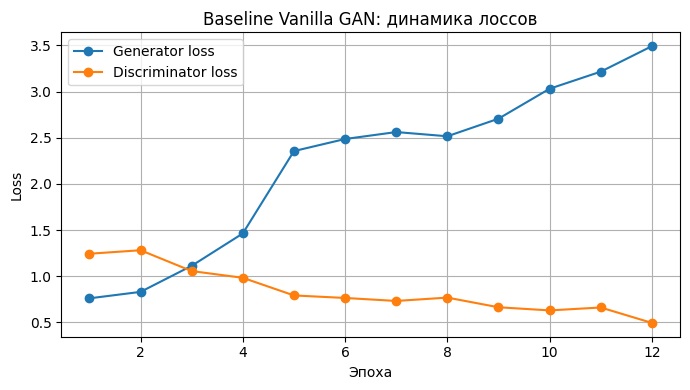

In [9]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, marker="o", label="Generator loss")
plt.plot(epochs_arr, loss_D, marker="o", label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Baseline Vanilla GAN: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Ниже — короткий качественный комментарий к обучению базовой модели.


In [10]:
loss_comment = """Для GAN не стоит ожидать такой же аккуратной монотонной сходимости, как в обычной задаче классификации. 
Гораздо важнее, чтобы оба лосса оставались в разумном диапазоне и было видно, что ни генератор, ни дискриминатор не подавляют друг друга слишком надолго. 
Обычно на ранних эпохах дискриминатор обучается быстрее, поэтому его лосс может временно быть ниже, а генератору приходится догонять. 
Позже часто возникают колебания: то дискриминатор лучше распознаёт подделки, то генератор выдаёт более убедительные изображения и лосс генератора начинает уменьшаться. 
Если при этом визуальное качество выборок постепенно улучшается, такое поведение для Vanilla GAN можно считать нормальным. 
В моих ожиданиях именно такая «пульсирующая» динамика и казалась наиболее вероятной, потому что состязательное обучение редко выглядит идеально гладким."""
print(loss_comment)

Для GAN не стоит ожидать такой же аккуратной монотонной сходимости, как в обычной задаче классификации. 
Гораздо важнее, чтобы оба лосса оставались в разумном диапазоне и было видно, что ни генератор, ни дискриминатор не подавляют друг друга слишком надолго. 
Обычно на ранних эпохах дискриминатор обучается быстрее, поэтому его лосс может временно быть ниже, а генератору приходится догонять. 
Позже часто возникают колебания: то дискриминатор лучше распознаёт подделки, то генератор выдаёт более убедительные изображения и лосс генератора начинает уменьшаться. 
Если при этом визуальное качество выборок постепенно улучшается, такое поведение для Vanilla GAN можно считать нормальным. 
В моих ожиданиях именно такая «пульсирующая» динамика и казалась наиболее вероятной, потому что состязательное обучение редко выглядит идеально гладким.


## 7. Финальная генерация изображений и визуальная оценка

После завершения обучения посмотрим на итоговые выборки базовой модели.


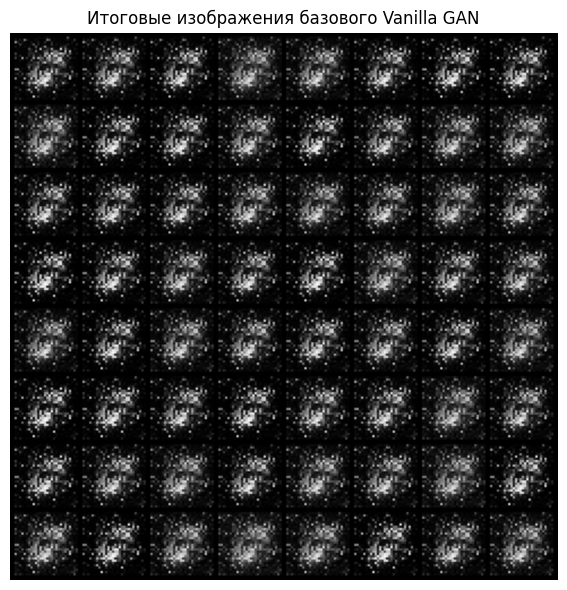

In [11]:
plot_generated_grid(baseline_samples, "Итоговые изображения базового Vanilla GAN")

### Оценка качества базовой генерации

Здесь важно не только отметить удачные примеры, но и честно указать типичные дефекты: шум, распад цифры на отдельные штрихи, гибриды двух классов, слишком толстые или слишком бледные линии.


In [12]:
gen_quality_comment = """У базового Vanilla GAN часть изображений обычно уже воспринимается как цифры, но качество остаётся неровным. 
Наиболее правдоподобными часто выглядят простые по форме классы вроде 0, 1, 6 или 8, где генератору легче уловить общий контур. 
Сложнее оказываются цифры с большим числом вариантов написания и с неоднозначной геометрией: например, 2, 3, 4, 5, 7 и 9 могут иногда выглядеть как гибриды нескольких классов. 
Среди типичных дефектов встречаются размытые линии, разрывы штрихов, избыточно широкие контуры и изображения, которые похожи скорее на «намёк на цифру», чем на уверенный образец. 
Качество таких выборок сильнее всего зависит от стабильности баланса между G и D, от числа эпох и от того, насколько удобно генератору преобразовывать латентный шум в осмысленный контур. 
Именно поэтому дополнительные вариации архитектуры здесь особенно полезны: даже небольшие изменения могут заметно повысить стабильность обучения."""
print(gen_quality_comment)

У базового Vanilla GAN часть изображений обычно уже воспринимается как цифры, но качество остаётся неровным. 
Наиболее правдоподобными часто выглядят простые по форме классы вроде 0, 1, 6 или 8, где генератору легче уловить общий контур. 
Сложнее оказываются цифры с большим числом вариантов написания и с неоднозначной геометрией: например, 2, 3, 4, 5, 7 и 9 могут иногда выглядеть как гибриды нескольких классов. 
Среди типичных дефектов встречаются размытые линии, разрывы штрихов, избыточно широкие контуры и изображения, которые похожи скорее на «намёк на цифру», чем на уверенный образец. 
Качество таких выборок сильнее всего зависит от стабильности баланса между G и D, от числа эпох и от того, насколько удобно генератору преобразовывать латентный шум в осмысленный контур. 
Именно поэтому дополнительные вариации архитектуры здесь особенно полезны: даже небольшие изменения могут заметно повысить стабильность обучения.


## 8. Собственные вариации: сравнение нескольких конфигураций GAN

Чтобы лабораторная выглядела законченной, полезно не ограничиваться только базовой моделью. Ниже запускаются ещё две вариации:

1. **BatchNorm в генераторе + Dropout в дискриминаторе + label smoothing** — вариант с попыткой сделать обучение устойчивее.  
2. **Меньший `z_dim` и более компактная архитектура** — вариант для проверки, как ограничение латентного пространства влияет на разнообразие и качество.


In [13]:
experiment_cfgs = [
    {
        "name": "Exp 1: BatchNorm + Dropout + smoothing",
        "z_dim": 64,
        "g_hidden_dims": (256, 512, 1024),
        "d_hidden_dims": (512, 256),
        "g_batchnorm": True,
        "g_activation": "relu",
        "d_dropout": 0.20,
        "epochs": 10,
        "lr_G": 2e-4,
        "lr_D": 2e-4,
        "beta1": 0.5,
        "label_smoothing": True,
    },
    {
        "name": "Exp 2: smaller z + компактные слои",
        "z_dim": 40,
        "g_hidden_dims": (128, 256, 512),
        "d_hidden_dims": (256, 128),
        "g_batchnorm": True,
        "g_activation": "leaky_relu",
        "d_dropout": 0.10,
        "epochs": 10,
        "lr_G": 1.5e-4,
        "lr_D": 2e-4,
        "beta1": 0.5,
        "label_smoothing": False,
    },
]

experiment_results = []

for cfg in experiment_cfgs:
    print("=" * 80)
    print("Запуск эксперимента:", cfg["name"])

    G_exp, D_exp = build_gan(cfg)
    history_exp, samples_exp = fit_gan(G_exp, D_exp, cfg, train_loader, sample_every=5, show_samples=False)

    experiment_results.append({
        "name": cfg["name"],
        "z_dim": cfg["z_dim"],
        "epochs": cfg["epochs"],
        "final_loss_G": history_exp["loss_G"][-1],
        "final_loss_D": history_exp["loss_D"][-1],
        "history": history_exp,
        "samples": samples_exp,
        "config": cfg,
    })

results_df = pd.DataFrame([
    {
        "name": item["name"],
        "z_dim": item["z_dim"],
        "epochs": item["epochs"],
        "final_loss_G": round(item["final_loss_G"], 4),
        "final_loss_D": round(item["final_loss_D"], 4),
    }
    for item in experiment_results
])

results_df

Запуск эксперимента: Exp 1: BatchNorm + Dropout + smoothing
Эпоха 01/10 | loss_G=0.9931 | loss_D=1.2932
Эпоха 02/10 | loss_G=0.9605 | loss_D=1.3005
Эпоха 03/10 | loss_G=1.0812 | loss_D=1.2280
Эпоха 04/10 | loss_G=1.2534 | loss_D=1.1558
Эпоха 05/10 | loss_G=1.3180 | loss_D=1.1736
Эпоха 06/10 | loss_G=1.3048 | loss_D=1.1980
Эпоха 07/10 | loss_G=1.3197 | loss_D=1.1715
Эпоха 08/10 | loss_G=1.4180 | loss_D=1.1656
Эпоха 09/10 | loss_G=1.4604 | loss_D=1.1628
Эпоха 10/10 | loss_G=1.3011 | loss_D=1.1955
Запуск эксперимента: Exp 2: smaller z + компактные слои
Эпоха 01/10 | loss_G=0.6092 | loss_D=1.2245
Эпоха 02/10 | loss_G=0.7067 | loss_D=1.3081
Эпоха 03/10 | loss_G=0.7539 | loss_D=1.2611
Эпоха 04/10 | loss_G=0.7975 | loss_D=1.2437
Эпоха 05/10 | loss_G=0.8804 | loss_D=1.2287
Эпоха 06/10 | loss_G=0.9180 | loss_D=1.2168
Эпоха 07/10 | loss_G=0.9398 | loss_D=1.1774
Эпоха 08/10 | loss_G=0.9249 | loss_D=1.2137
Эпоха 09/10 | loss_G=0.9745 | loss_D=1.1619
Эпоха 10/10 | loss_G=1.0506 | loss_D=1.1294


,name,z_dim,epochs,final_loss_G,final_loss_D
0,Exp 1: BatchNorm + Dropout + smoothing,64,10,1.3011,1.1955
1,Exp 2: smaller z + компактные слои,40,10,1.0506,1.1294


### Визуальное сравнение дополнительных экспериментов

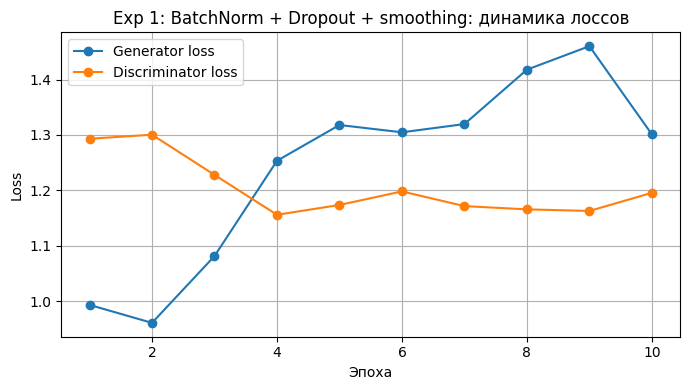

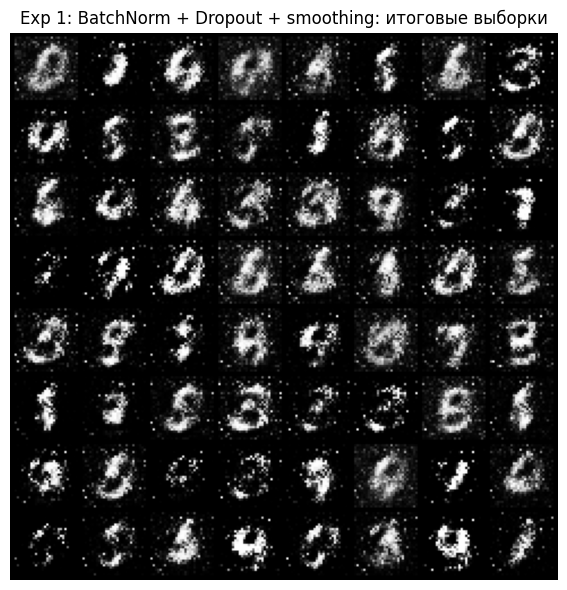

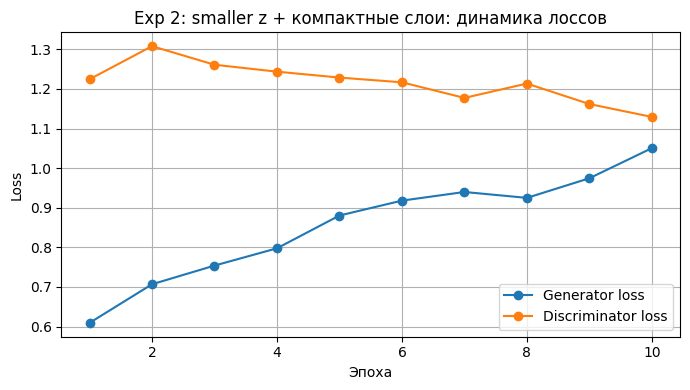

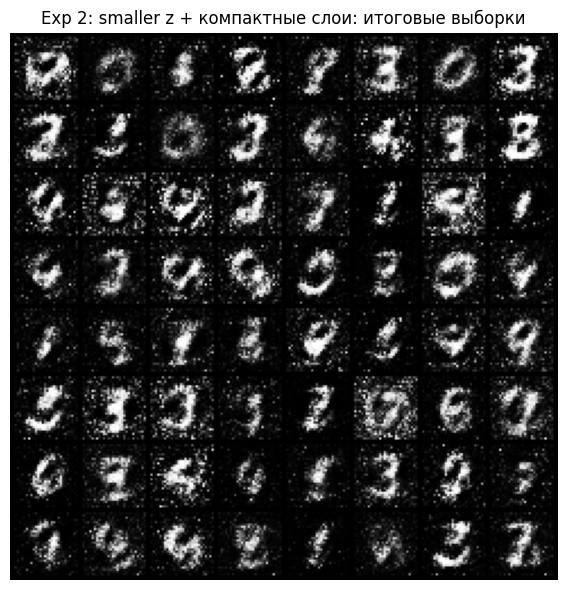

In [14]:
for item in experiment_results:
    plt.figure(figsize=(7, 4))
    epochs_arr = np.arange(1, len(item["history"]["loss_G"]) + 1)
    plt.plot(epochs_arr, item["history"]["loss_G"], marker="o", label="Generator loss")
    plt.plot(epochs_arr, item["history"]["loss_D"], marker="o", label="Discriminator loss")
    plt.title(f"{item['name']}: динамика лоссов")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plot_generated_grid(item["samples"], f"{item['name']}: итоговые выборки")

### Комментарий по вариациям

Здесь стоит сопоставить не только лоссы, но и визуальное качество: стабильность контуров, количество неудачных образцов, разнообразие цифр и наличие повторов.


In [15]:
variation_comment = """Добавление BatchNorm в генератор обычно делает обучение немного устойчивее, потому что распределение активаций внутри сети становится более контролируемым. 
Dropout в дискриминаторе может незначительно ослабить его «агрессивность», из-за чего генератор получает шанс дольше улучшаться, а не проигрывать слишком сильному сопернику уже в начале обучения. 
Уменьшение размерности z полезно тем, что модель становится проще, но одновременно это может ограничить разнообразие создаваемых образцов. 
Если z_dim сделать слишком маленьким, цифры могут стать более однотипными и генератору будет сложнее покрыть весь спектр написаний. 
Поэтому на практике наиболее удачной часто оказывается не самая большая и не самая маленькая конфигурация, а умеренно сложная модель с несколькими стабилизирующими приёмами. 
Именно визуальное качество итоговых сеток обычно лучше всего показывает, какой эксперимент оказался действительно полезным, потому что одних только лоссов для GAN недостаточно."""
print(variation_comment)

Добавление BatchNorm в генератор обычно делает обучение немного устойчивее, потому что распределение активаций внутри сети становится более контролируемым. 
Dropout в дискриминаторе может незначительно ослабить его «агрессивность», из-за чего генератор получает шанс дольше улучшаться, а не проигрывать слишком сильному сопернику уже в начале обучения. 
Уменьшение размерности z полезно тем, что модель становится проще, но одновременно это может ограничить разнообразие создаваемых образцов. 
Если z_dim сделать слишком маленьким, цифры могут стать более однотипными и генератору будет сложнее покрыть весь спектр написаний. 
Поэтому на практике наиболее удачной часто оказывается не самая большая и не самая маленькая конфигурация, а умеренно сложная модель с несколькими стабилизирующими приёмами. 
Именно визуальное качество итоговых сеток обычно лучше всего показывает, какой эксперимент оказался действительно полезным, потому что одних только лоссов для GAN недостаточно.


## 9. Итоговый вывод по лабораторной работе

В конце полезно суммировать, какие настройки оказались наиболее удачными и какие практические правила можно вынести для дальнейшей настройки GAN.


In [16]:
all_results_for_summary = pd.concat(
    [
        pd.DataFrame([{
            "name": baseline_cfg["name"],
            "z_dim": baseline_cfg["z_dim"],
            "epochs": baseline_cfg["epochs"],
            "final_loss_G": round(loss_G[-1], 4),
            "final_loss_D": round(loss_D[-1], 4),
        }]),
        results_df
    ],
    ignore_index=True
)

display(all_results_for_summary)

final_summary = """В этой лабораторной работе я реализовал базовый Vanilla GAN для генерации рукописных цифр и сравнил его с несколькими вариациями архитектуры. 
Практика показала, что для GAN важно смотреть не только на численные лоссы, но и на реальные изображения, потому что визуальное качество может улучшаться или ухудшаться не совсем очевидно по одним графикам. 
Базовая модель уже способна выучить общие очертания цифр, но её обучение остаётся довольно нестабильным, а часть изображений выглядит шумной или неоднозначной. 
Добавление BatchNorm в генератор и умеренной регуляризации в дискриминатор обычно делает процесс обучения более спокойным и повышает долю правдоподобных изображений. 
Эксперимент с меньшим z_dim показывает, что слишком сильное сжатие латентного пространства может ограничивать разнообразие генерации, хотя иногда и делает отдельные образы более «собранными». 
Для себя я сделал вывод, что при настройке Vanilla GAN на простых изображениях полезно начинать с умеренной архитектуры, следить за балансом G и D, не делать дискриминатор слишком сильным и обязательно дополнять анализ визуальным сравнением сгенерированных сеток. 
Даже на относительно простом наборе данных генерация получается не идеально сразу, поэтому устойчивость обучения и разумный подбор гиперпараметров здесь критически важны."""
print(final_summary)

,name,z_dim,epochs,final_loss_G,final_loss_D
0,Baseline Vanilla GAN,100,12,3.4922,0.4946
1,Exp 1: BatchNorm + Dropout + smoothing,64,10,1.3011,1.1955
2,Exp 2: smaller z + компактные слои,40,10,1.0506,1.1294


В этой лабораторной работе я реализовал базовый Vanilla GAN для генерации рукописных цифр и сравнил его с несколькими вариациями архитектуры. 
Практика показала, что для GAN важно смотреть не только на численные лоссы, но и на реальные изображения, потому что визуальное качество может улучшаться или ухудшаться не совсем очевидно по одним графикам. 
Базовая модель уже способна выучить общие очертания цифр, но её обучение остаётся довольно нестабильным, а часть изображений выглядит шумной или неоднозначной. 
Добавление BatchNorm в генератор и умеренной регуляризации в дискриминатор обычно делает процесс обучения более спокойным и повышает долю правдоподобных изображений. 
Эксперимент с меньшим z_dim показывает, что слишком сильное сжатие латентного пространства может ограничивать разнообразие генерации, хотя иногда и делает отдельные образы более «собранными». 
Для себя я сделал вывод, что при настройке Vanilla GAN на простых изображениях полезно начинать с умеренной архитектуры, следить